<h1 style="font-weight: 400;">Seasonal Agriculture Performance Analysis</h1>

<h2 style="font-weight: 400;">Major Data Analytics Project</h2>

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

<h2 style="font-weight: 400;">Project Goal</h2>
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

<h2 style="font-weight: 400;">1. Problem Statement</h2>

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

<h2 style="font-weight: 400;">2. Project Objectives</h2>

- Understand the structure and quality of the agriculture dataset.
- Clean and prepare the data for the analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agriculture performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate, and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

<h2 style="font-weight: 400;">3. Dataset</h2>

The dataset contains farm-level agriculture records covering different seasons, locations, crops, environmental conditions, farm practices, production, cost, revenue, profit, and resource usage.

> **Dataset File:** `seasonal_agriculture_performance_dataset.csv`

In [2]:
#Import Required Libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x:f"{x:,.2f}")

In [3]:
# Load the Dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


<h2 style="font-weight: 400;">4. Initial Data Understanding </h2>

In [4]:
# Dataset Shape
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])


Number of rows: 4000
Number of columns: 28


In [5]:
# Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
# Bottom 5 Rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [7]:
# Random Sample of Records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [8]:
# Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [9]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
# Dataset Statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [11]:
# Categorical Summary
df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


<h2 style="font-weight: 400;">5. Data Cleaning</h2>

In [12]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({"Missing_Count":missing,"Missing_Percentage":missing_percentage.round(2)})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


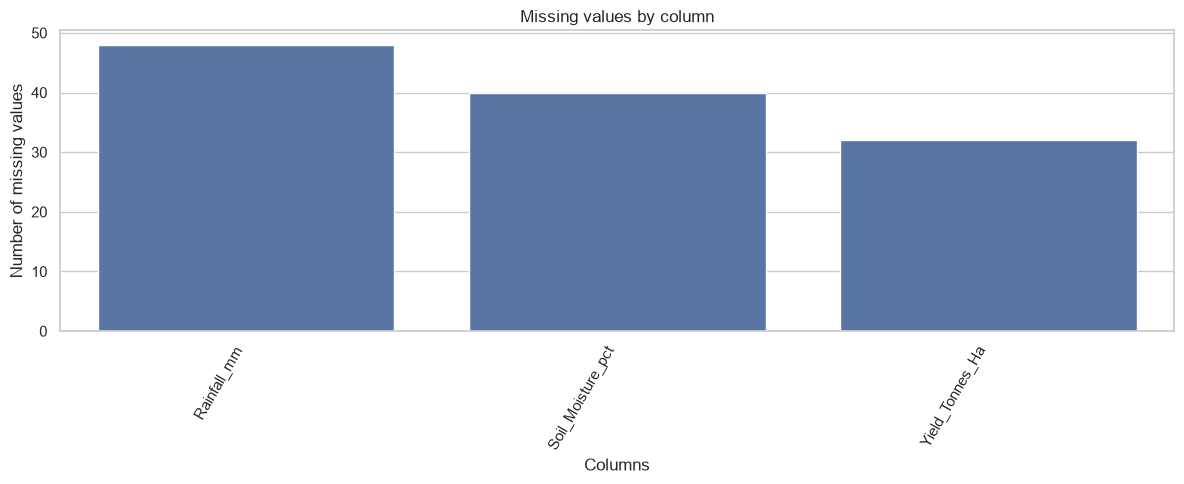

In [13]:
# Visualize missing value

plt.figure(figsize=(12, 5))

missing_plot = missing[missing > 0]

if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha='right')
    plt.ylabel("Number of missing values")
    plt.xlabel("Columns")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing value found.")

In [14]:
# Duplicate record

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows : ", duplicate_count)

Number of duplicate rows :  0


In [15]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [16]:
# Check data type again
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [17]:
# Check unique values for the categorical column
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [18]:
# Check missing value after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

Rainfall_mm                      48
Soil_Moisture_pct                40
Yield_Tonnes_Ha                  32
Farm_ID                           0
Irrigation_Method                 0
Water_Efficiency_t_per_1000m3     0
Water_Used_m3                     0
Profit_INR                        0
Revenue_INR                       0
Total_Cost_INR                    0
dtype: int64

In [19]:
# Median imputing for numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


<h2 style="font-weight: 400;">6: Feature/Variable Review</h2>
Reviewing the available variables and classifying them conceptually as:

- Identifier Variable
- Categorical Variable
- Numerical Variable
- Environmental Variable
- Operational Variable
- Production/Performance Variable
- Economic Variable

In [20]:
# Numerical and Categorical columns
Numerical_columns = df.select_dtypes(include=np.number).columns.to_list()
Categorical_columns = df.select_dtypes(include='object').columns.to_list()

print("Numerical columns:")
print(Numerical_columns)
print("\nCategorical columns:")
print(Categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


<h2 style="font-weight: 400;">7: Statistics Analysis</h2>
Performing descriptive statistics analysis to understand the distribution and variation of the data.

In [21]:
# Descriptive statistics
stats = df[Numerical_columns].describe().T
stats["Range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,Range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [22]:
# Median and Standard Deviation
statistical_summary = pd.DataFrame({
    "Mean": df[Numerical_columns].mean(),
    "Median": df[Numerical_columns].median(),
    "Standard Deviation": df[Numerical_columns].std(),
    "Min": df[Numerical_columns].min(),
    "Max": df[Numerical_columns].max()
})

statistical_summary

,Mean,Median,Standard Deviation,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [23]:
# Seasonal descriptive summary
season_summary = df.groupby("Season")[Numerical_columns].agg(["median", "mean", "std"])

print(season_summary)

       Farm_Area_Hectares           Rainfall_mm                \
                   median mean  std      median   mean    std   
Season                                                          
Kharif               8.18 7.94 4.28      853.10 849.20 183.69   
Rabi                 7.68 7.75 4.18      432.20 437.62 175.35   
Zaid                 8.09 8.09 4.16      288.20 304.65 157.24   

       Avg_Temperature_C            Humidity_pct             \
                  median  mean  std       median  mean  std   
Season                                                        
Kharif             28.50 28.45 2.51        71.90 71.81 8.86   
Rabi               23.50 23.49 2.46        58.10 57.89 9.00   
Zaid               31.00 31.04 2.55        52.35 52.01 9.05   

       Sunlight_Hours_Day           Soil_pH           Soil_Moisture_pct        \
                   median mean  std  median mean  std            median  mean   
Season                                                              

<h2>8. Univariate Analysis</h2>

Univariate analysis examines one variable at a time to understand its distribution, frequency, central tendency, and variation.

Suitable plots are created and interpreted for:

- Important categorical variables
- Important numerical variables
- Seasonal distribution
- Production/Performance distribution
- Economic distribution

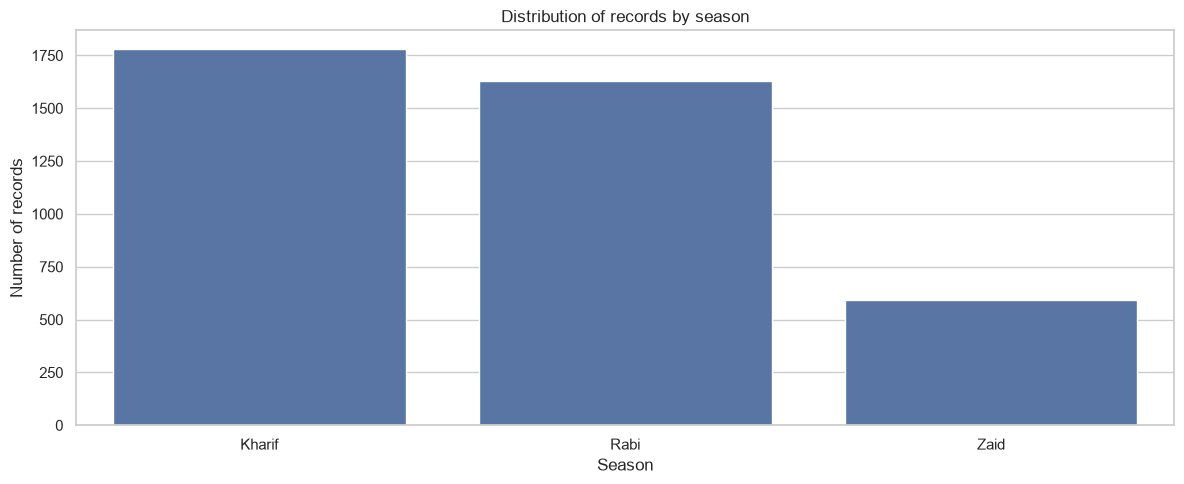

In [24]:
# Univariate Season Distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of records by season")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

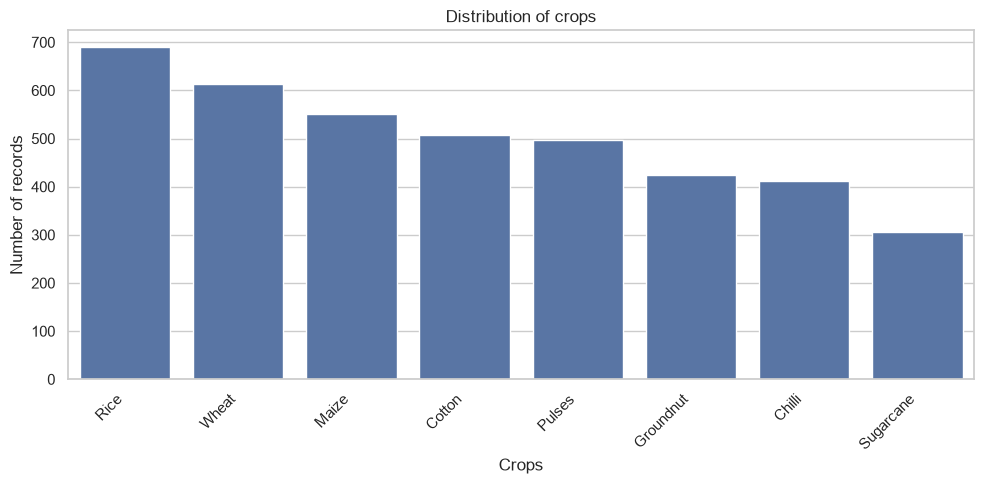

In [25]:
# Univariate: Crop Distribution
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of crops")
plt.xlabel("Crops")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

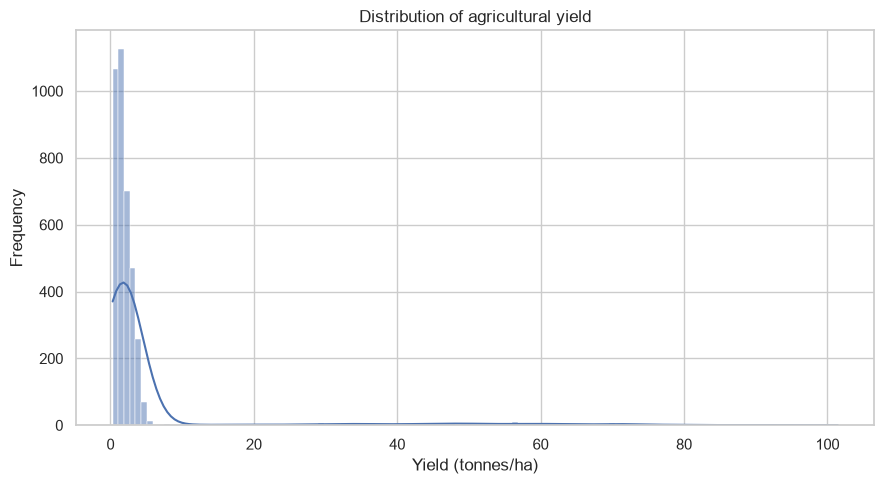

In [26]:
# Univariate: Yield Distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of agricultural yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

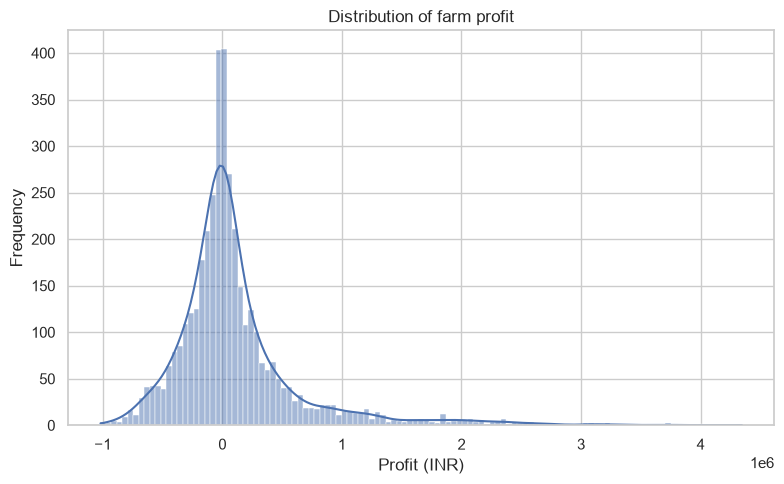

In [27]:
# Univariate: Profit Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of farm profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

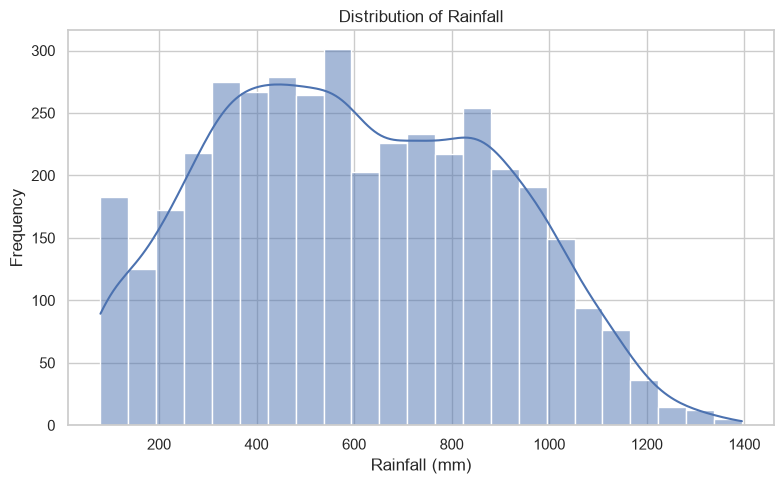

In [28]:
# Univariate: Rainfall Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<h2 style="font-weight: 400;">9. Outlier Analysis</h2>
Investigated potential outliers using statistical and visual methods.

<h2 style="font-weight: 400;">Univariate: Season Distribution</h2>
A pie chart is used to visualize the proportion of records across different seasons.

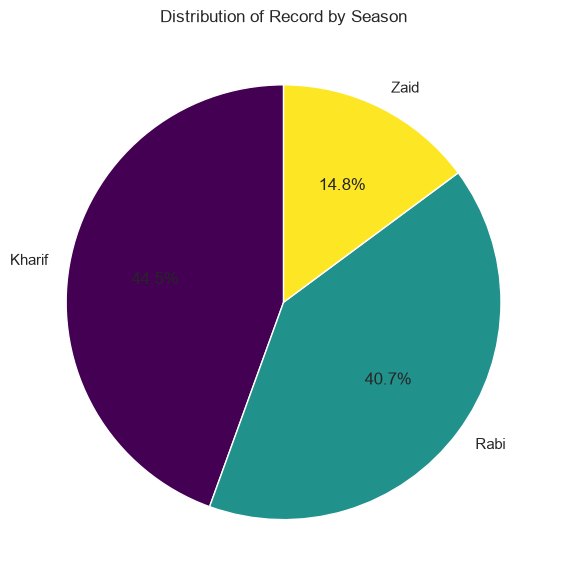

In [29]:
# Univariate: Season Distribution
plt.figure(figsize=(6, 6))

df["Season"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    cmap="viridis"
)

plt.title("Distribution of Record by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [30]:
# IQR-based outlier summary for numerical columns
outlier_summary = []

for col in Numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier Count", ascending=False
)

outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


<h2 style="font-weight: 400;">10. Bivariate Analysis</h2>
Bivariate analysis examines the relationship and differences between two variables.

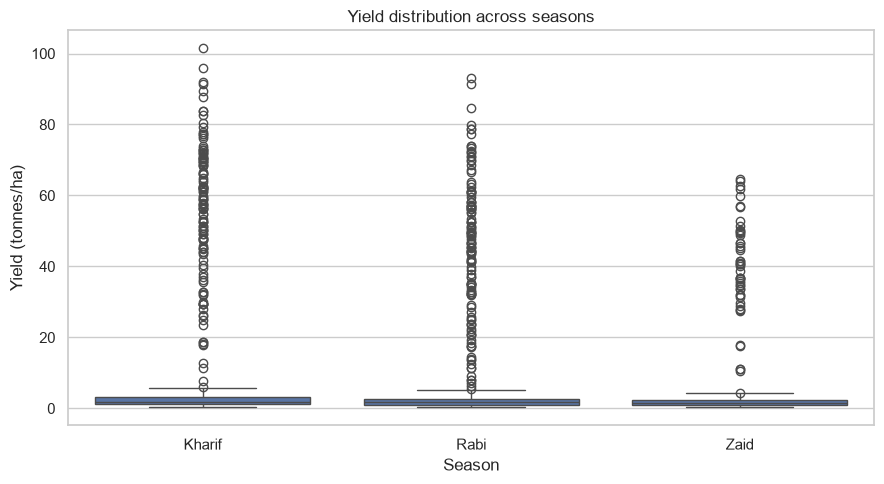

In [31]:
# Bivariate: Season versus Yield
plt.figure(figsize=(9, 5))

sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")

plt.title("Yield distribution across seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

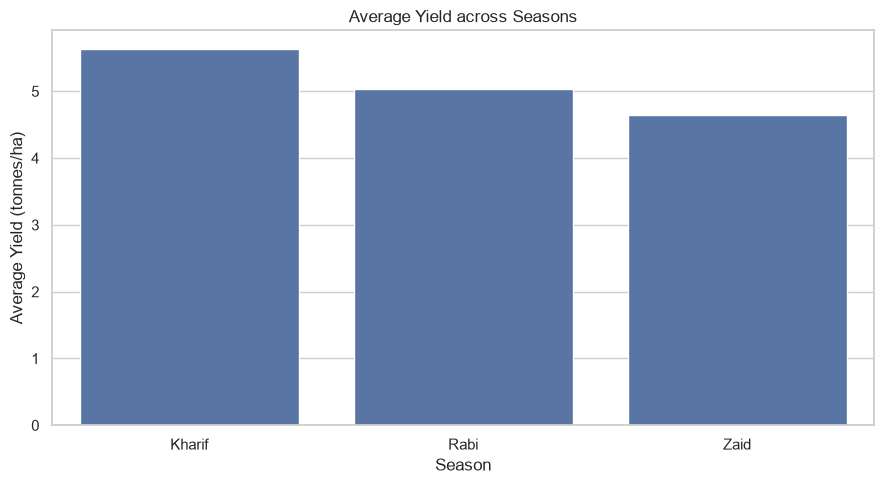

In [43]:
# Bivariate: Season versus Yield - Bar Plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar = None
)

plt.title("Average Yield across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

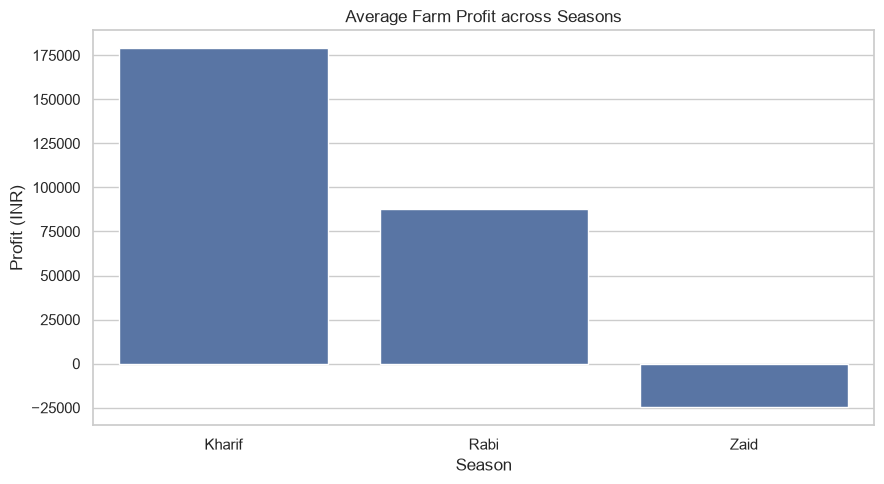

In [41]:
# Bivariate: Season versus Profit - Bar Plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar = None
)

plt.title("Average Farm Profit across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

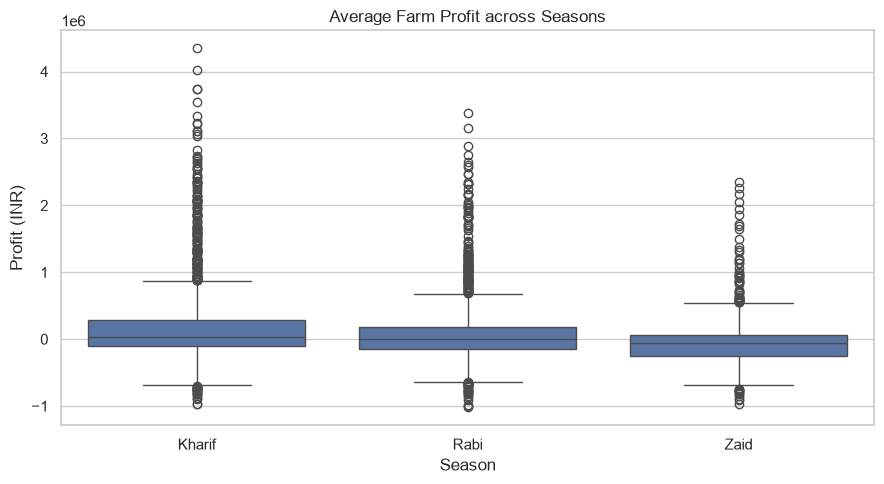

In [36]:
# Bivariate: Season versus Profit - Outlier Plot
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR",
)

plt.title("Average Farm Profit across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

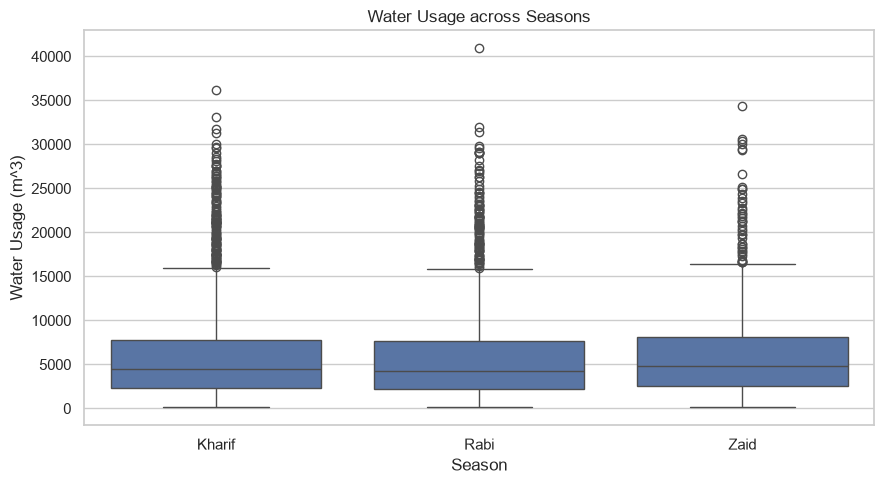

In [38]:
# Bivariate: Season versus water
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
)

plt.title("Water Usage across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Usage (m^3)")
plt.tight_layout()
plt.show()

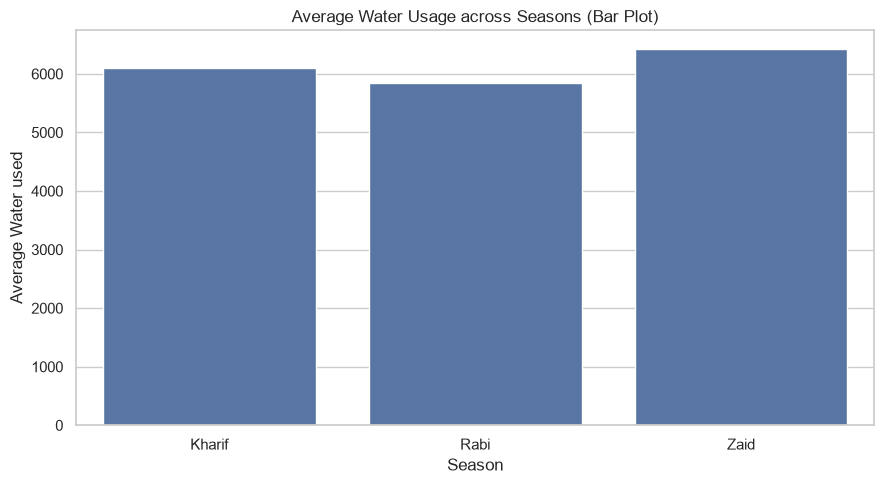

In [40]:
# Bivariate: Season versus water
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    errorbar = None
)

plt.title("Average Water Usage across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water used")
plt.tight_layout()
plt.show()

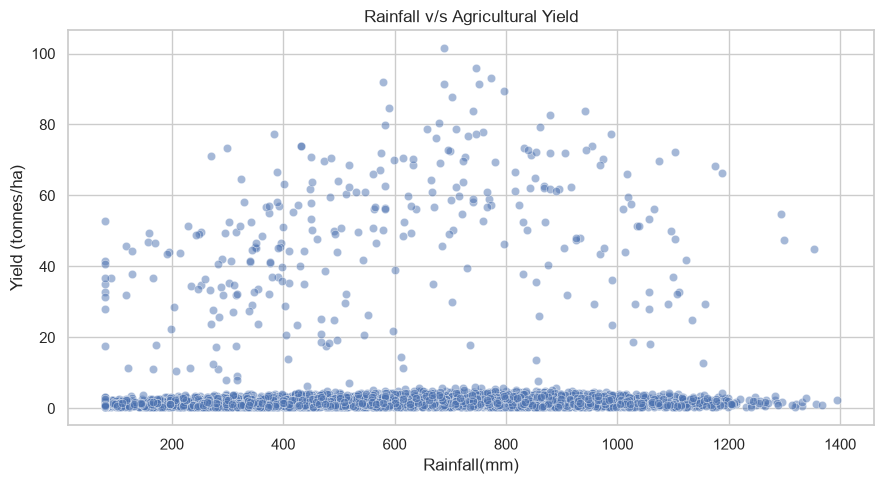

In [44]:
# Bivariate: Rainfall versus Yield
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha = 0.5
)

plt.title("Rainfall v/s Agricultural Yield")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

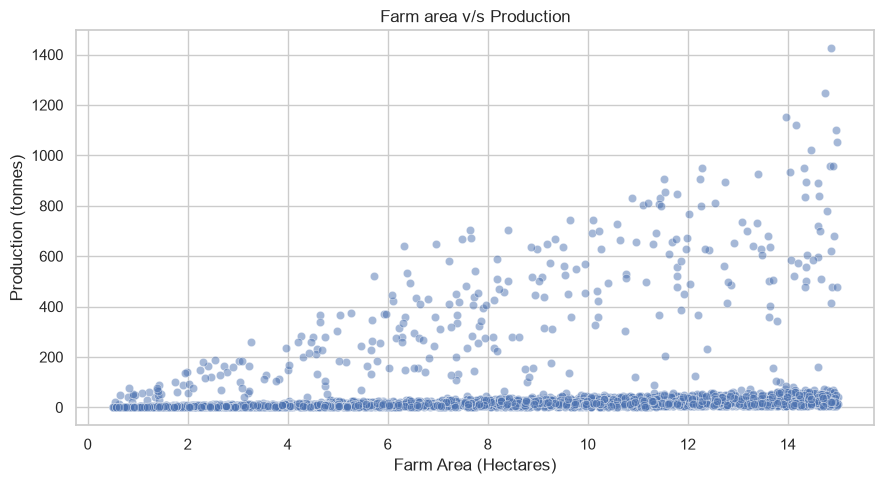

In [45]:
# Bivariate: Farm area versus Production
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    alpha = 0.5
)

plt.title("Farm area v/s Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

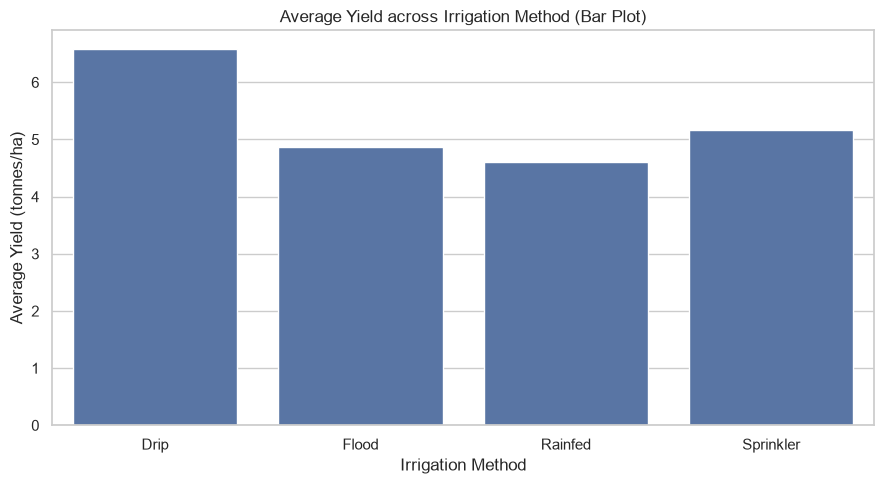

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar = None
)

plt.title("Average Yield across Irrigation Method (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

<h2 style="font-weight: 400;">11. Multivariate Analysis</h2>

Multivariate analysis examines more than two variables together.

Using Multivariate plots to investigate how seasons interacts with other dimensions such as crop, region, environmental conditions, resource.

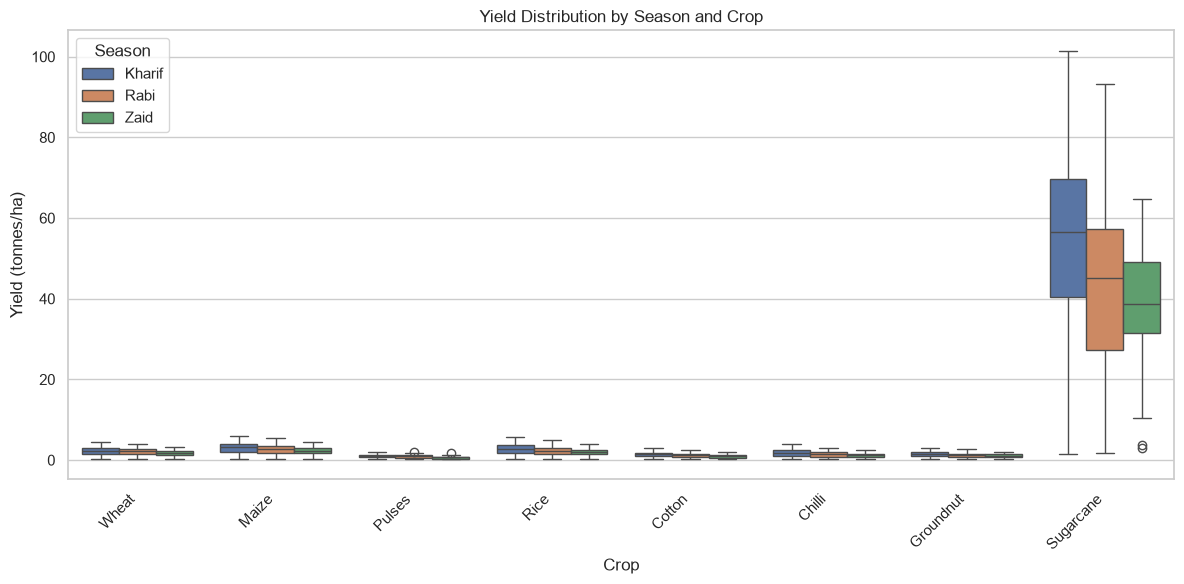

In [50]:
# Multivariate: Season, Crop versus Yield - Box Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.xticks(rotation = 45 , ha="right")
plt.title("Yield Distribution by Season and Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

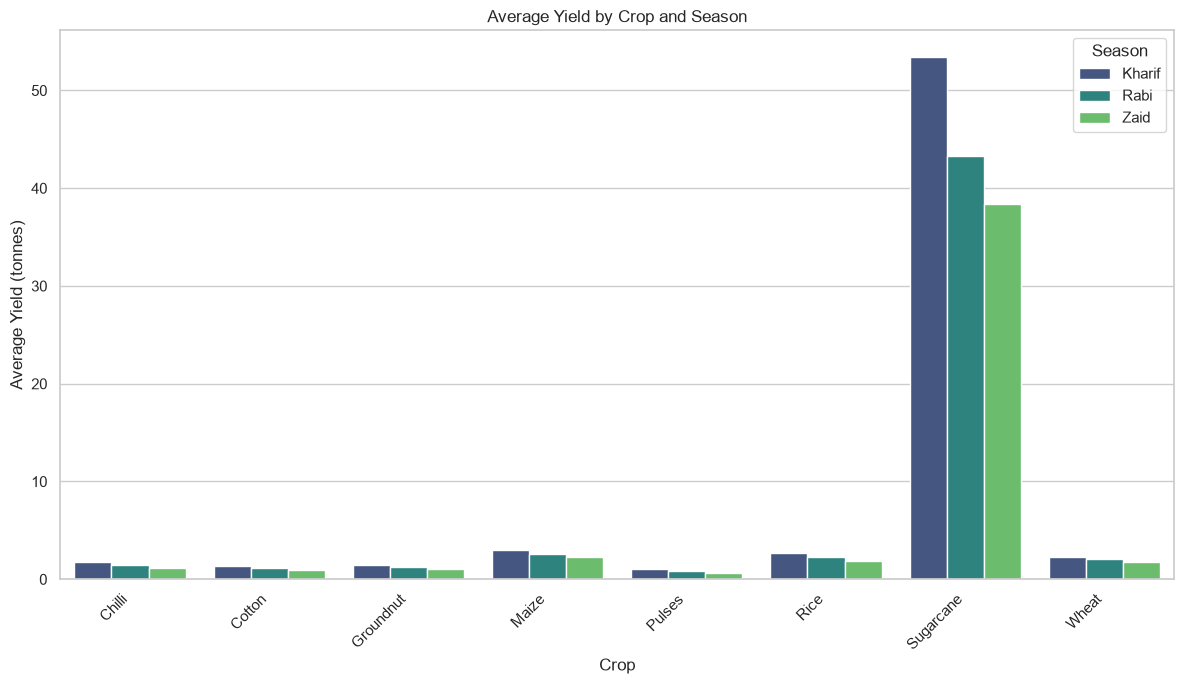

In [55]:
# Average yield by crop and season
crop_season_summary = (
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
      .mean()
      .reset_index(name="Average_Yield")
)

crop_season_summary
# Average Yield by Crop and Season
plt.figure(figsize=(12, 7))

sns.barplot(
    data=crop_season_summary.reset_index(),
    x="Crop",
    y="Average_Yield",
    hue="Season",
    palette="viridis"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

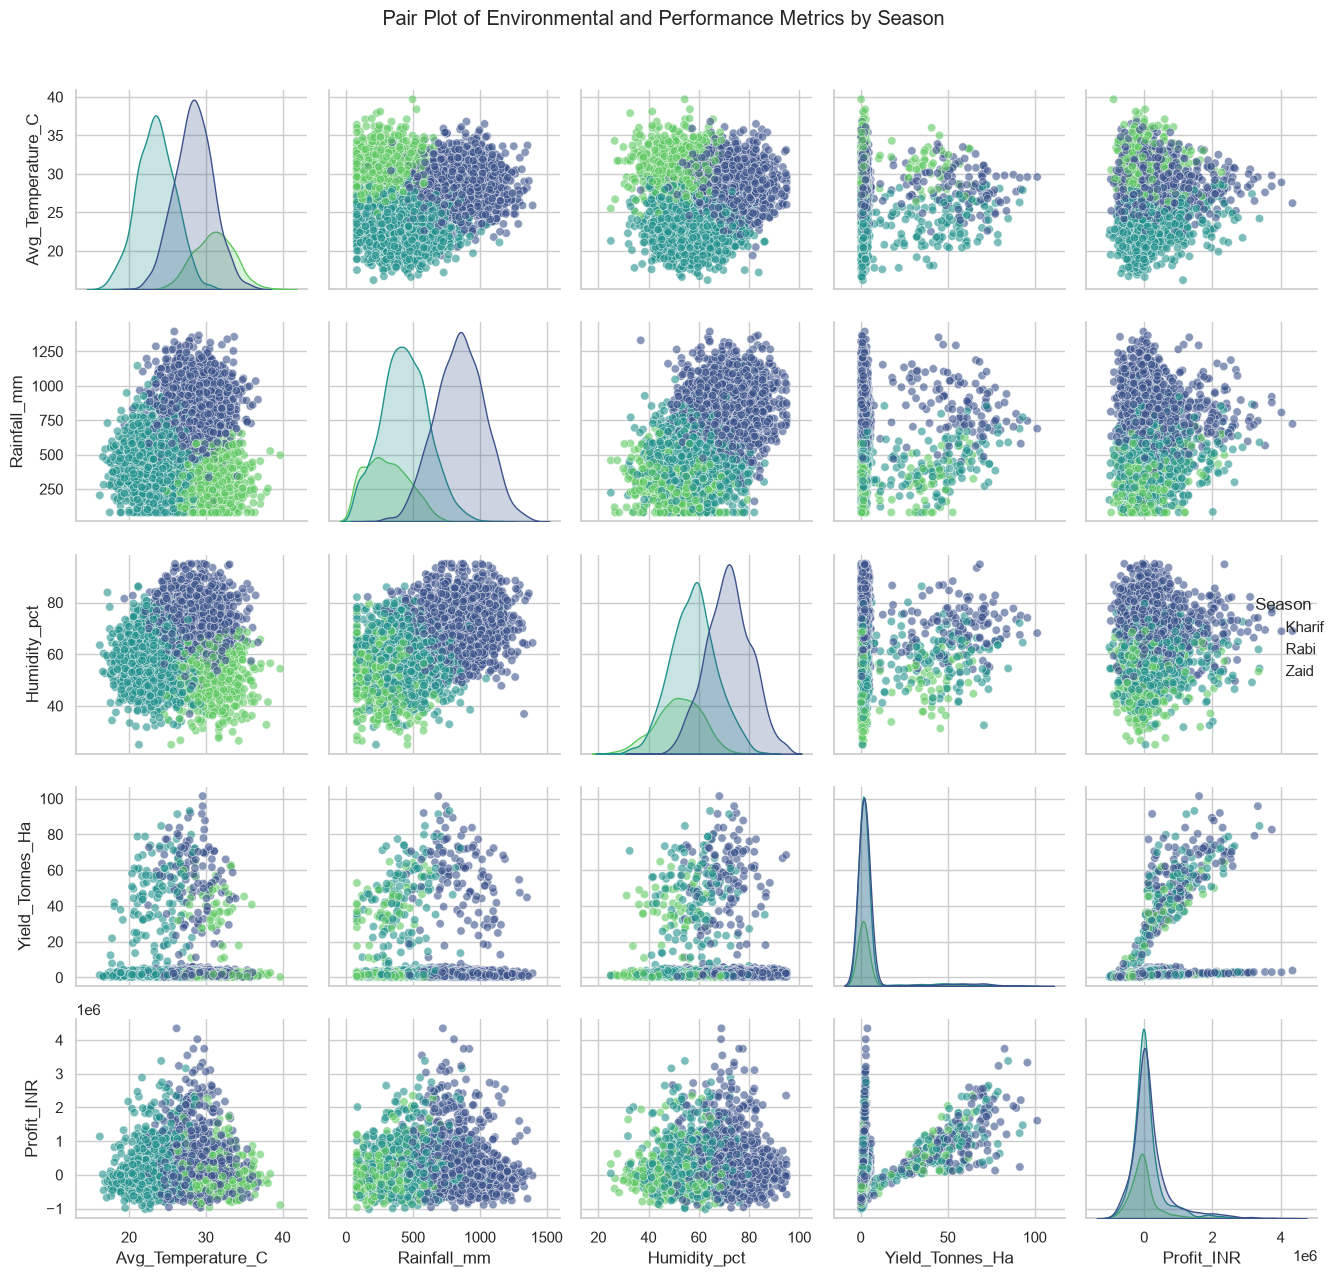

In [58]:
# Multivariate: Environmental and Performance Metrics by Season

selected = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    data=df[selected],
    hue="Season",
    palette="viridis",
    plot_kws={"alpha": 0.6}
)

plt.suptitle("Pair Plot of Environmental and Performance Metrics by Season", y=1.02)

plt.tight_layout()
plt.show()

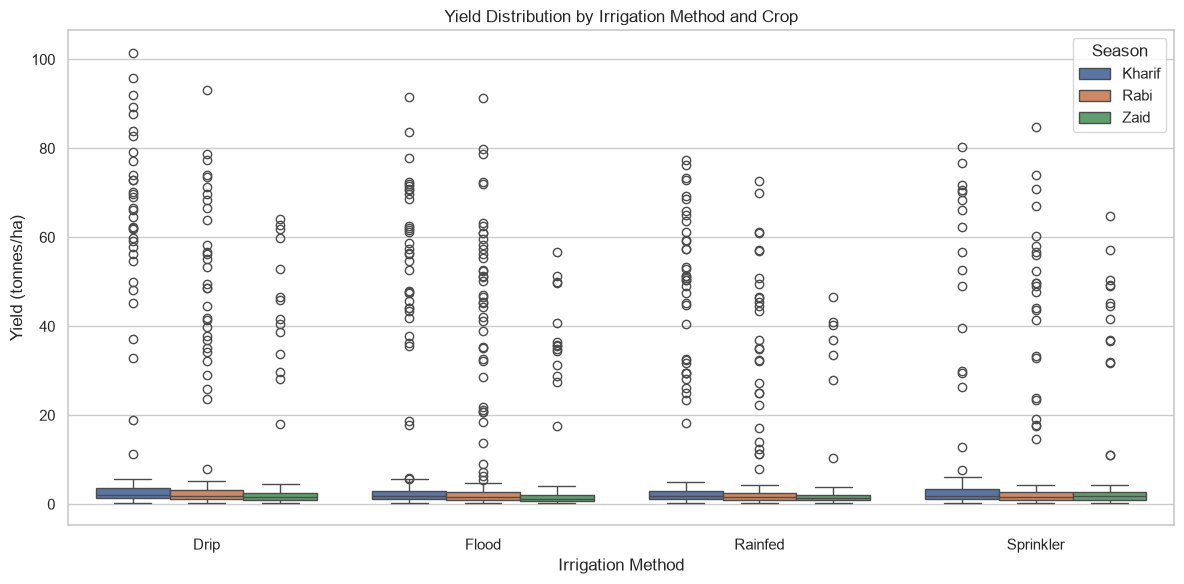

In [59]:
# Multivariate: Season, Irrigation versus Yield - Box Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)
plt.title("Yield Distribution by Irrigation Method and Crop")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title='Season')
plt.tight_layout()
plt.show()

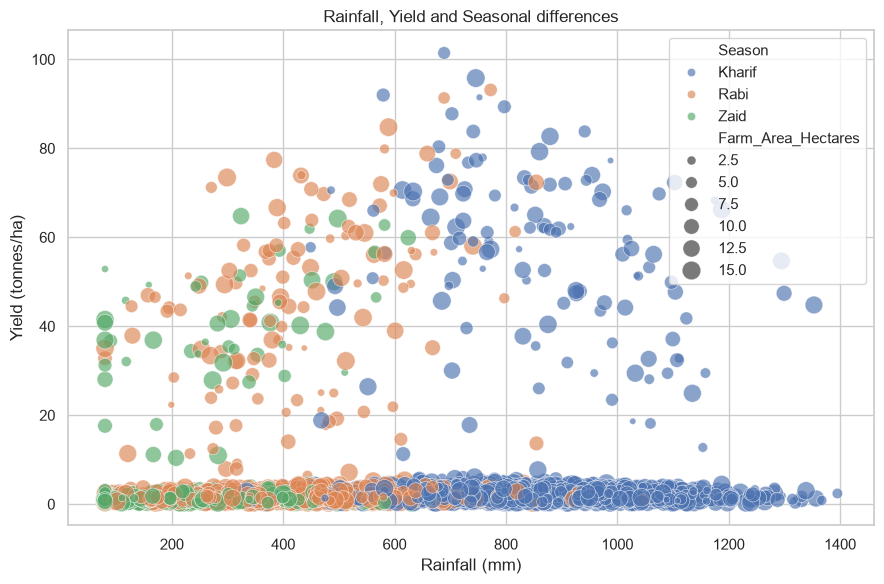

In [60]:
# Multivariate: Rainfall, Yield and Season
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)

plt.title("Rainfall, Yield and Seasonal differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

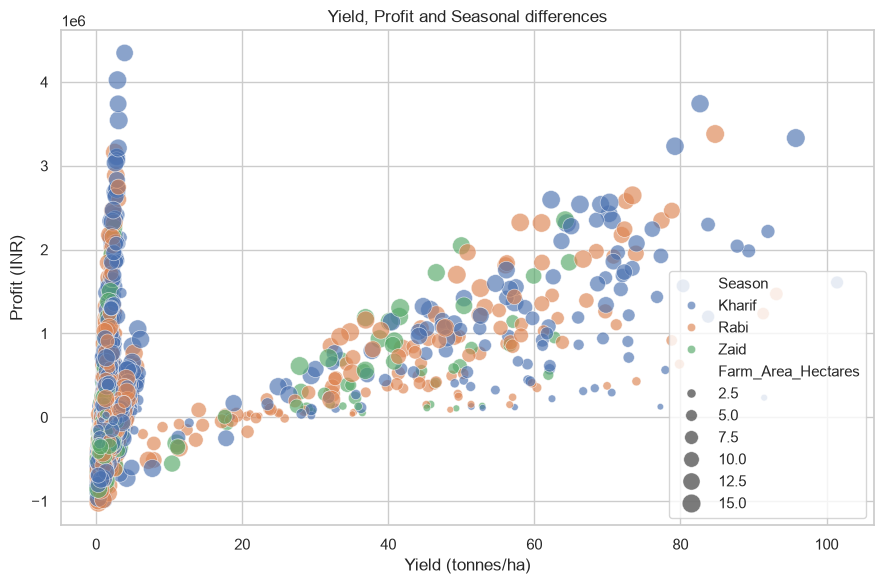

In [61]:
# Multivariate: Profit, Yield and Season
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)

plt.title("Yield, Profit and Seasonal differences")
plt.ylabel("Profit (INR)")
plt.xlabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

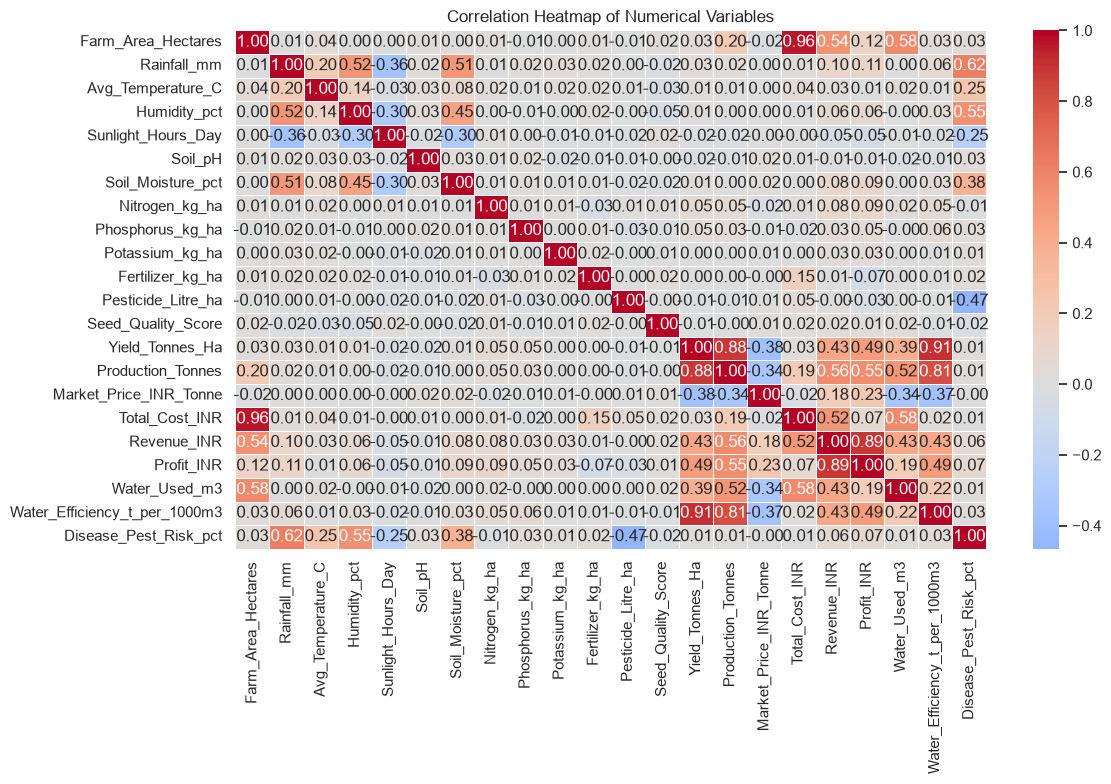

In [62]:
# Correlation Heatmap for Numerical Variables

plt.figure(figsize=(12, 8))

correlation_matrix = df[Numerical_columns].corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

<h2 style="font-weight: 400;">12. Seasonal Comparsion</h2>


In [65]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [66]:
# Compare crop performance within each season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .sort_values(
        ["Season", "Average_Yield"],
        ascending=[True, False]
    )
)

crop_season_summary

Average_Yield  Average_Water_Efficiency  Average_Profit
Season Crop                                                              
Kharif Sugarcane          53.46                     36.00    1,000,790.81
       Maize               2.97                      6.05      -39,332.67
       Rice                2.70                      2.17      -64,903.40
       Wheat               2.25                      4.76     -105,871.87
       Chilli              1.73                      3.26      954,380.42
       Groundnut           1.48                      3.58      108,265.44
       Cotton              1.37                      2.13      216,999.55
       Pulses              1.04                      3.35       43,338.90
Rabi   Sugarcane          43.29                     27.92      731,612.86
       Maize               2.60                      5.46      -89,133.40
       Rice                2.32                      1.84      -98,427.87
       Wheat               2.06                      4.69     -119,954.57
       Chilli              1.47                      2.89      638,572.50
       Groundnut           1.23                      2.90       10,416.54
       Cotton              1.20                      1.94      107,343.59
       Pulses              0.88                      2.70      -14,309.14
Zaid   Sugarcane          38.42                     23.39      583,635.80
       Maize               2.29                      4.75     -194,049.17
       Rice                1.90                      1.53     -227,239.34
       Wheat               1.75                      4.02     -193,208.95
       Chilli              1.20                      2.20      448,659.09
       Groundnut           1.04                      2.47      -68,872.50
       Cotton              0.96                      1.49      -53,925.34
       Pulses              0.67                      1.95     -139,227.81

<h2 style="font-weight: 400;">13. Additional Analyses</h2>

The sections below extend the notebook with four analyses that were not covered above: 
**(A) Regional (State-wise) seasonal performance**, 
**(B) Disease/Pest risk as an outcome variable**,
**(C) Economic performance deep-dive (margins, cost structure, loss rates)**, and 
**(D) Resource-use efficiency & input-output relationships**.

<h3 style="font-weight: 400;">13A. Regional (State-wise) Seasonal Performance</h3>

Compares yield and profit across **State × Season**, since a single overall "Season" average can hide very different regional pictures.

In [68]:
# 13A.1 - State x Season: Average Profit (pivot table)
state_season_profit = df.groupby(["State", "Season"])["Profit_INR"].mean().unstack().round(0)
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,316.00","26,316.00","-84,085.00"
Gujarat,"217,051.00","82,846.00","-106,930.00"
Karnataka,"201,226.00","70,953.00","23,311.00"
Madhya Pradesh,"134,242.00","61,576.00",210.00
Maharashtra,"168,801.00","159,582.00","-40,598.00"
Punjab,"133,779.00","169,295.00","62,110.00"
Tamil Nadu,"211,304.00","70,457.00","-15,175.00"
Telangana,"199,668.00","62,825.00","-34,621.00"


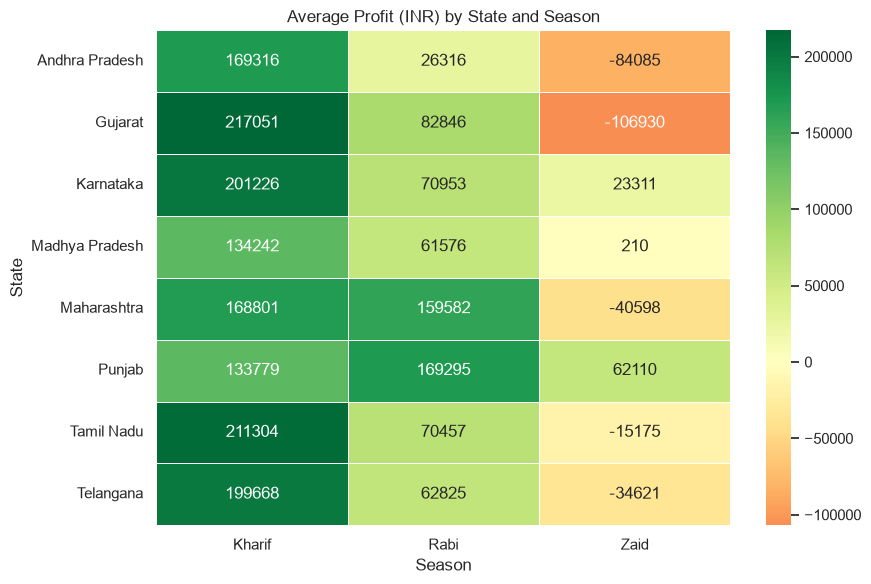

In [69]:
# 13A.2 - State x Season Profit Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Average Profit (INR) by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


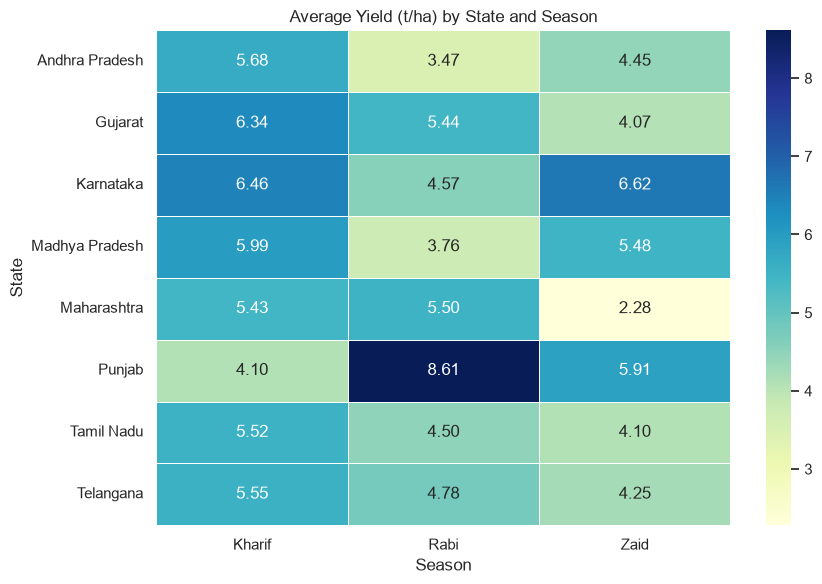

In [70]:
# 13A.3 - State x Season: Average Yield (pivot table + heatmap)
state_season_yield = df.groupby(["State", "Season"])["Yield_Tonnes_Ha"].mean().unstack().round(2)

plt.figure(figsize=(9, 6))
sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Average Yield (t/ha) by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.tight_layout()
plt.show()


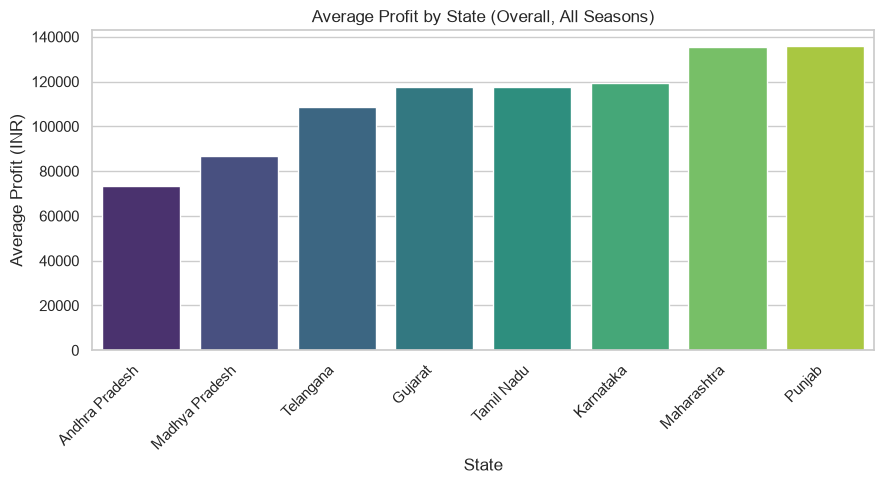

,Avg_Yield,Avg_Profit,Records
State,,,
Andhra Pradesh,4.63,"73,453.53",529
Madhya Pradesh,4.99,"86,840.76",497
Telangana,5.04,"108,829.62",516
Gujarat,5.66,"117,568.24",488
Tamil Nadu,4.88,"117,744.75",485
Karnataka,5.69,"119,422.34",489
Maharashtra,5.02,"135,428.86",512
Punjab,6.12,"136,025.64",484


In [71]:
# 13A.4 - Overall State ranking by average profit
state_summary = (
    df.groupby("State")
    .agg(
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit=("Profit_INR", "mean"),
        Records=("Farm_ID", "count")
    )
    .round(2)
    .sort_values("Avg_Profit")
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=state_summary.reset_index(),
    x="State",
    y="Avg_Profit",
    order=state_summary.index,
    hue="State",
    palette="viridis",
    legend=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Profit by State (Overall, All Seasons)")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

state_summary


<h3 style="font-weight: 400;">13B. Disease/Pest Risk as an Outcome Variable</h3>

Examines `Disease_Pest_Risk_pct` against environmental drivers (rainfall, humidity), season, region, and its downstream relationship with yield and profit.

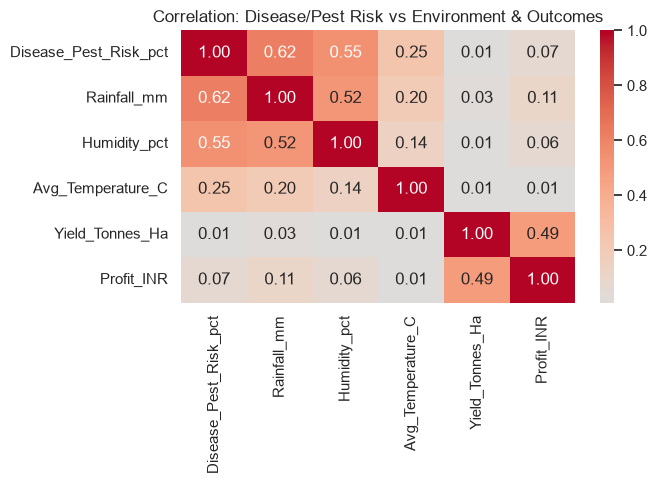

In [73]:
# 13B.1 - Correlation of Disease/Pest Risk with environmental and outcome variables
risk_corr = df[[
    "Disease_Pest_Risk_pct", "Rainfall_mm", "Humidity_pct",
    "Avg_Temperature_C", "Yield_Tonnes_Ha", "Profit_INR"
]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(risk_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation: Disease/Pest Risk vs Environment & Outcomes")
plt.tight_layout()
plt.show()


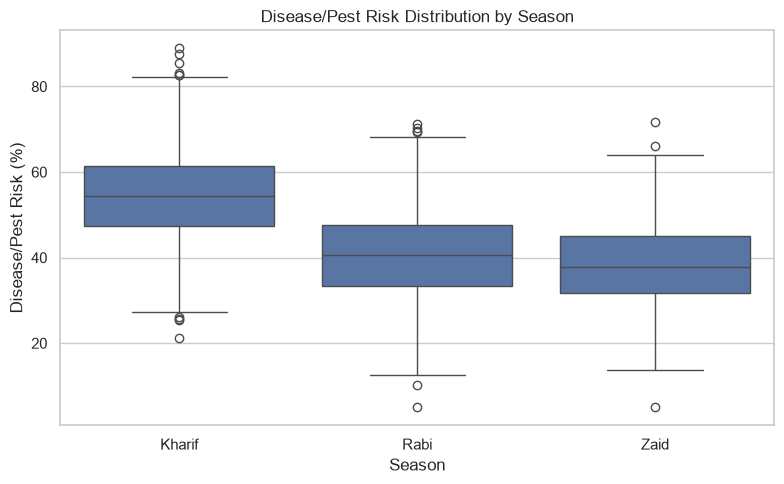

Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64

In [74]:
# 13B.2 - Disease/Pest Risk by Season
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Disease/Pest Risk Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.tight_layout()
plt.show()

df.groupby("Season")["Disease_Pest_Risk_pct"].mean().round(2)


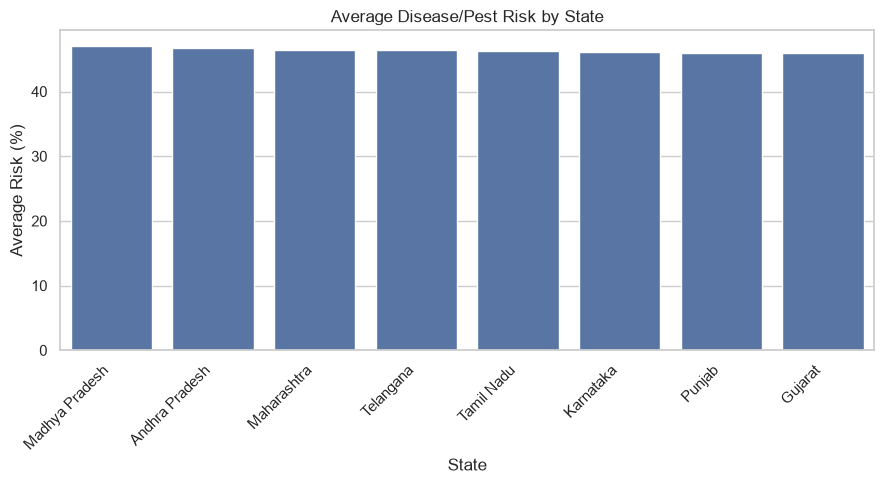

In [75]:
# 13B.3 - Disease/Pest Risk by State (checking for a regional pattern)
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="State",
    y="Disease_Pest_Risk_pct",
    estimator="mean",
    errorbar=None,
    order=df.groupby("State")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False).index
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Disease/Pest Risk by State")
plt.xlabel("State")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()


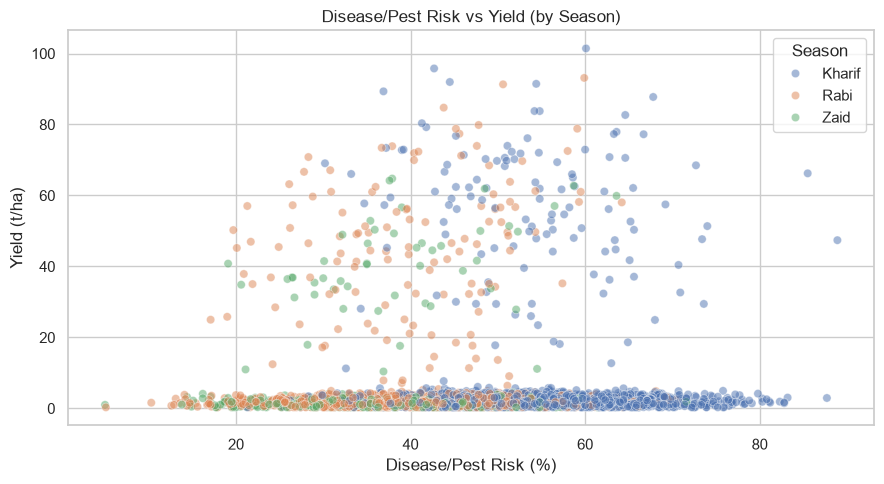

In [76]:
# 13B.4 - Does higher risk actually translate into lower yield or profit?
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.5
)
plt.title("Disease/Pest Risk vs Yield (by Season)")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.show()


<h3 style="font-weight: 400;">13C. Economic Performance Deep-Dive (Margins, Cost Structure, Loss Rates)</h3>

Goes beyond average profit to examine **profit margin %**, **cost-to-revenue ratio**, and **share of loss-making farms** — a more decision-relevant view of seasonal economic health.

In [78]:
# 13C.1 - Derived economic ratios
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100
df["Cost_Revenue_Ratio"] = df["Total_Cost_INR"] / df["Revenue_INR"]

df[["Profit_Margin_pct", "Cost_Revenue_Ratio"]].describe().round(2)


,Profit_Margin_pct,Cost_Revenue_Ratio
count,"4,000.00","4,000.00"
mean,-45.49,1.45
std,158.09,1.58
min,"-1,461.85",0.14
25%,-60.19,0.67
50%,1.15,0.99
75%,32.89,1.60
max,85.92,15.62


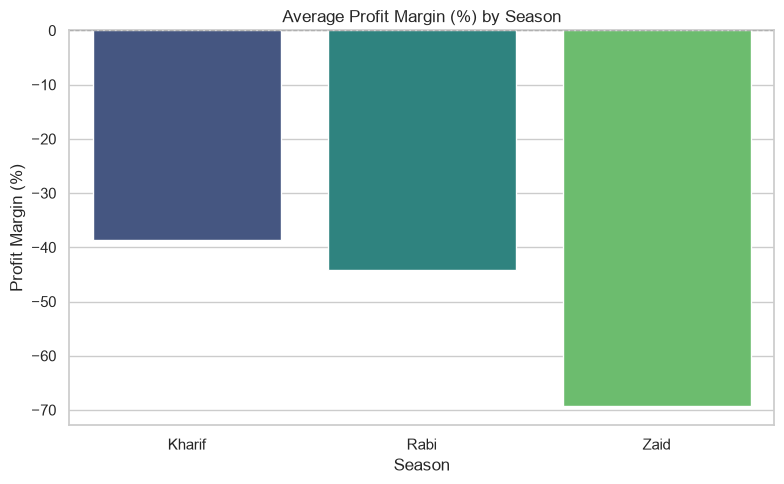

Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64

In [79]:
# 13C.2 - Average Profit Margin (%) by Season
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Season",
    y="Profit_Margin_pct",
    estimator="mean",
    errorbar=None,
    hue="Season",
    palette="viridis",
    legend=False
)
plt.title("Average Profit Margin (%) by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

df.groupby("Season")["Profit_Margin_pct"].mean().round(2)


C:\Users\Pushpendra\AppData\Local\Temp\ipykernel_20428\3565055947.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_rate = df.groupby("Season").apply(lambda g: (g["Profit_INR"] < 0).mean() * 100).round(2)


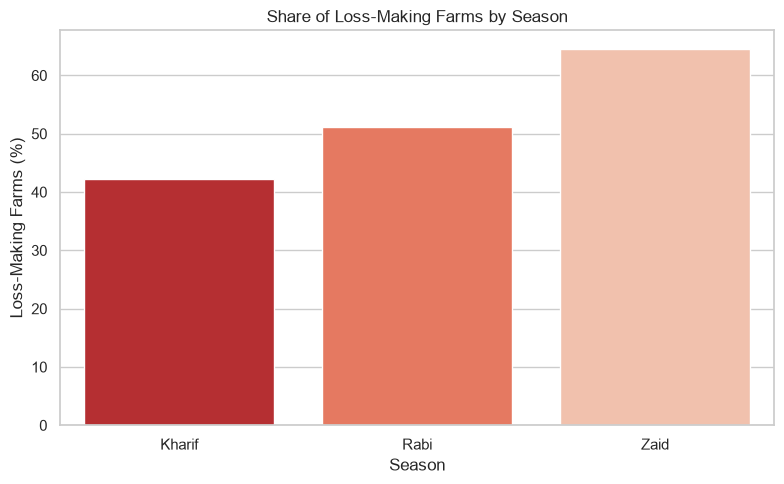

Season
Kharif   42.21
Rabi     51.14
Zaid     64.48
Name: Loss_Making_Farms_pct, dtype: float64

In [80]:
# 13C.3 - Share of loss-making farms by Season
loss_rate = df.groupby("Season").apply(lambda g: (g["Profit_INR"] < 0).mean() * 100).round(2)
loss_rate = loss_rate.rename("Loss_Making_Farms_pct")

plt.figure(figsize=(8, 5))
sns.barplot(x=loss_rate.index, y=loss_rate.values, hue=loss_rate.index, palette="Reds_r", legend=False)
plt.title("Share of Loss-Making Farms by Season")
plt.xlabel("Season")
plt.ylabel("Loss-Making Farms (%)")
plt.tight_layout()
plt.show()

loss_rate


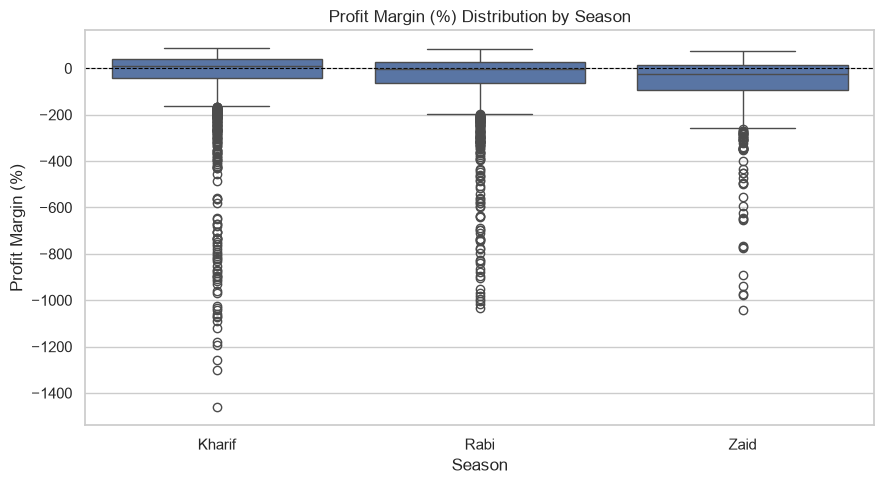

In [81]:
# 13C.4 - Profit margin distribution by Season (boxplot, shows spread not just mean)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Season", y="Profit_Margin_pct")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Profit Margin (%) Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()


In [82]:
# 13C.5 - Aggregate vs per-farm profitability (why totals can be misleading)
total_revenue = df["Revenue_INR"].sum()
total_cost = df["Total_Cost_INR"].sum()
avg_cost_revenue_ratio = df["Cost_Revenue_Ratio"].mean()

print(f"Total Revenue (all farms): INR {total_revenue:,.0f}")
print(f"Total Cost (all farms):    INR {total_cost:,.0f}")
print(f"Aggregate Profit:          INR {total_revenue - total_cost:,.0f}")
print(f"Average per-farm Cost/Revenue ratio: {avg_cost_revenue_ratio:.2f}")
print(f"Share of farms with cost > revenue: {(df['Cost_Revenue_Ratio'] > 1).mean()*100:.1f}%")


Total Revenue (all farms): INR 2,551,440,192
Total Cost (all farms):    INR 2,105,214,332
Aggregate Profit:          INR 446,225,860
Average per-farm Cost/Revenue ratio: 1.45
Share of farms with cost > revenue: 49.1%


<h3 style="font-weight: 400;">13D. Resource-Use Efficiency & Input-Output Relationships</h3>

Tests whether input intensity (fertilizer, NPK, seed quality) actually drives yield, and compares irrigation methods on water efficiency.

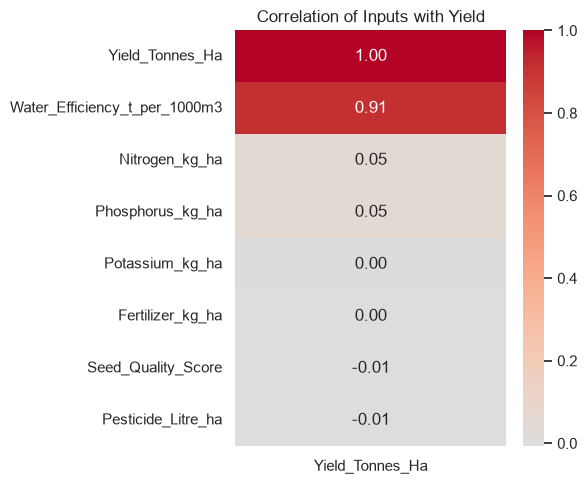

In [84]:
# 13D.1 - Correlation of input variables with Yield
input_cols = [
    "Fertilizer_kg_ha", "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Pesticide_Litre_ha", "Seed_Quality_Score", "Water_Efficiency_t_per_1000m3",
    "Yield_Tonnes_Ha"
]

input_corr = df[input_cols].corr()[["Yield_Tonnes_Ha"]].sort_values("Yield_Tonnes_Ha", ascending=False)

plt.figure(figsize=(6, 5))
sns.heatmap(input_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Inputs with Yield")
plt.tight_layout()
plt.show()


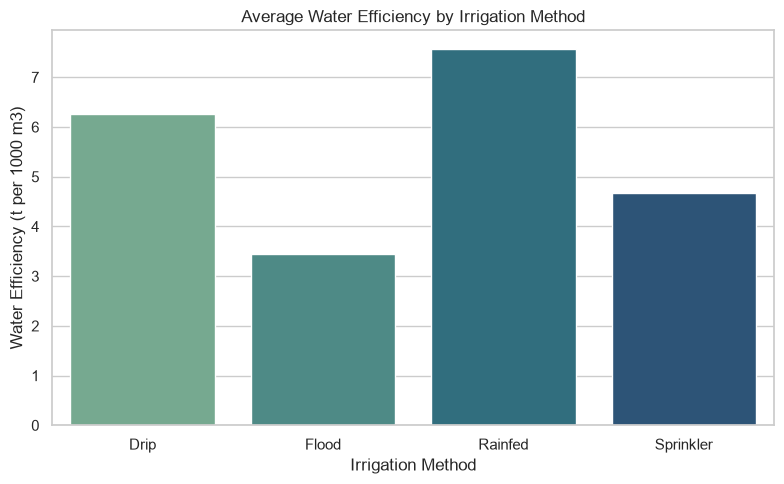

Irrigation_Method
Drip        6.27
Flood       3.44
Rainfed     7.56
Sprinkler   4.67
Name: Water_Efficiency_t_per_1000m3, dtype: float64

In [85]:
# 13D.2 - Water efficiency by Irrigation Method
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None,
    hue="Irrigation_Method",
    palette="crest",
    legend=False
)
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (t per 1000 m3)")
plt.tight_layout()
plt.show()

df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().round(2)


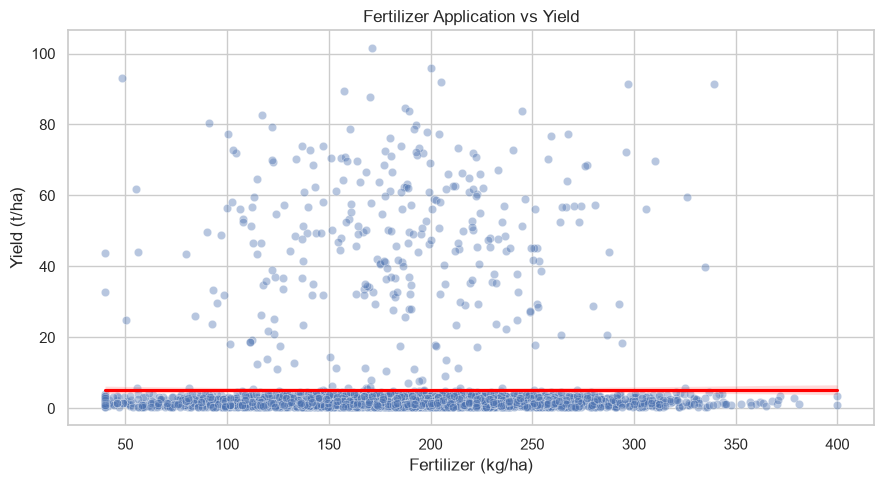

In [86]:
# 13D.3 - Fertilizer vs Yield (scatter) - visually checking the near-zero correlation
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", alpha=0.4)
sns.regplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", scatter=False, color="red")
plt.title("Fertilizer Application vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.show()


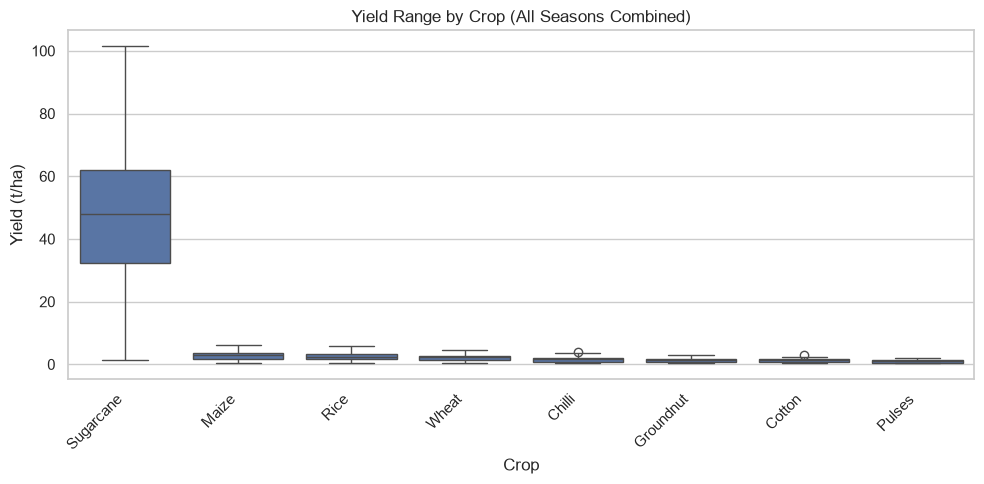

,min,mean,max
Crop,,,
Sugarcane,1.39,46.64,101.44
Maize,0.30,2.71,6.08
Rice,0.30,2.43,5.70
Wheat,0.30,2.11,4.56
Chilli,0.30,1.54,3.90
Groundnut,0.30,1.32,3.02
Cotton,0.30,1.23,2.90
Pulses,0.30,0.92,2.09


In [87]:
# 13D.4 - Crop yield range across all seasons (crop dominates over season)
crop_yield_range = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
    .agg(["min", "mean", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    order=crop_yield_range.index
)
plt.xticks(rotation=45, ha="right")
plt.title("Yield Range by Crop (All Seasons Combined)")
plt.xlabel("Crop")
plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.show()

crop_yield_range


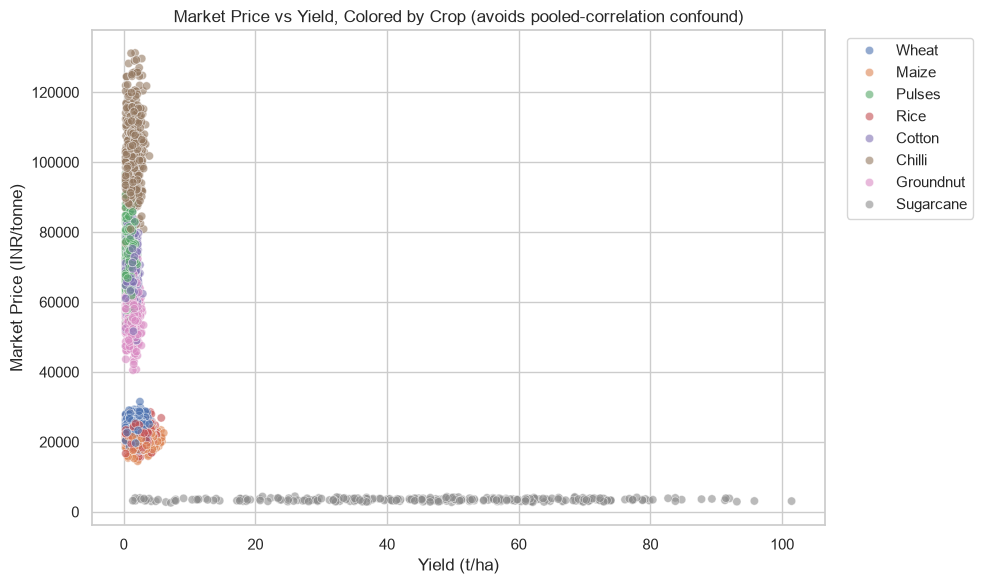

C:\Users\Pushpendra\AppData\Local\Temp\ipykernel_20428\2705182291.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  within_crop_corr = df.groupby("Crop").apply(


Crop
Chilli       0.05
Cotton       0.04
Groundnut   -0.00
Maize       -0.02
Pulses      -0.06
Rice        -0.02
Sugarcane    0.02
Wheat       -0.05
dtype: float64

In [88]:
# 13D.5 - Market price vs Yield, WITHIN crop (avoids the pooled/confounded correlation)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Market_Price_INR_Tonne",
    hue="Crop",
    alpha=0.6
)
plt.title("Market Price vs Yield, Colored by Crop (avoids pooled-correlation confound)")
plt.xlabel("Yield (t/ha)")
plt.ylabel("Market Price (INR/tonne)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Correlation computed within each crop separately
within_crop_corr = df.groupby("Crop").apply(
    lambda g: g["Yield_Tonnes_Ha"].corr(g["Market_Price_INR_Tonne"])
).round(2)
within_crop_corr


## 14. Key Insights / Conclusion

> Format: **Observation → Evidence → Interpretation → Limitation → Recommendation**

### Insight 1 — Kharif outperforms other seasons on yield, but the gap is modest
- **Observation:** Kharif has the highest average yield (5.63 t/ha), followed by Rabi (5.04 t/ha) and Zaid (4.64 t/ha).
- **Evidence:** Season-wise groupby aggregation of `Yield_Tonnes_Ha` across 4,000 cleaned records.
- **Interpretation:** Kharif's monsoon-driven rainfall and typically favorable temperature/humidity likely support marginally better crop growth conditions than the drier Zaid season.
- **Limitation:** The gap (~1 t/ha) is small relative to within-season variability (std deviation is large per season), and the average is skewed upward by Sugarcane's very high yield scale, which is disproportionately represented differently across seasons.

### Insight 2 — Nearly half of all farm records are loss-making, and losses worsen from Kharif → Rabi → Zaid
- **Observation:** 49.15% of all farms show negative profit; loss-making share rises from 42.2% (Kharif) to 51.1% (Rabi) to 64.5% (Zaid). Average profit margin is -38.6%, -44.3%, and -69.3% respectively.
- **Evidence:** `(Profit_INR < 0)` share computed by season; `Profit_Margin_pct = Profit_INR / Revenue_INR × 100` averaged by season.
- **Interpretation:** Profitability, not just yield, is the more decisive story — Zaid isn't just "lower yield," it is disproportionately loss-making, implying costs stay high (irrigation in a dry season, pest control) even as output/revenue falls.
- **Limitation:** The dataset's cost and revenue fields are synthetic/simulated; a near-70% negative margin in Zaid is extreme and should be validated against real-world agricultural economics before being treated as fact (it may reflect how the dataset was generated rather than real seasonal economics).

### Insight 3 — Regional performance varies more than seasonal performance, and the "worst season" isn't consistent across states
- **Observation:** Zaid is profitable in Punjab (₹62,110 avg. profit) and Karnataka (₹23,311) but deeply loss-making in Gujarat (₹106,930) and Andhra Pradesh (₹84,085).
- **Evidence:** `State × Season` pivot of mean `Profit_INR`.
- **Interpretation:** Whatever Punjab and Karnataka are doing differently in Zaid (crop choice, irrigation infrastructure, or local climate) is worth isolating, since it contradicts the overall "Zaid is bad" narrative.
- **Limitation:** State sample sizes per season are moderate (~160 records each), so state-season means carry meaningful uncertainty; this is a hypothesis-generating finding, not a confirmed causal one.

### Insight 4 — Yield is driven far more by water efficiency and irrigation method than by fertilizer/nutrient dosage
- **Observation:** `Water_Efficiency_t_per_1000m3` correlates strongly with yield (r = 0.91), while Nitrogen, Phosphorus, Potassium, and Fertilizer kg/ha all correlate at essentially r ≈ 0.00–0.05.
- **Evidence:** Pearson correlation matrix of numeric columns against `Yield_Tonnes_Ha`.
- **Interpretation:** In this dataset, how efficiently water is converted to output matters far more than how much fertilizer is applied — this could reflect genuine agronomic reality (water is often the binding constraint) or how the dataset was simulated.
- **Limitation:** Correlation ≠ causation, and water efficiency is partly *derived from* yield (`yield / water used`), so this relationship is partly definitional/circular rather than a fully independent driver — it should not be presented as a clean causal finding.

### Insight 5 — Disease/pest risk is weather-driven and season-driven, not region-driven
- **Observation:** Disease/Pest Risk correlates with Rainfall (r = 0.62) and Humidity (r = 0.55); Kharif shows the highest average risk (54.5%) vs. Zaid's 38.2%. Across states, risk barely varies (45.9%–47.1%).
- **Evidence:** Correlation matrix + groupby means by `Season` and by `State`.
- **Interpretation:** Pest/disease pressure appears tied to monsoon-associated humidity and rainfall rather than to any state-specific factor (soil, farming practice, or local pest ecology) — the risk is climatic, not geographic.
- **Limitation:** Risk shows almost no correlation with yield (r = 0.01) or profit (r = 0.07) in this data, which is counter-intuitive and suggests either the risk field is not strongly tied to outcomes in this dataset, or farmers' pesticide spend is already neutralizing the risk before it affects yield.

### Insight 6 — Market price and yield move in opposite directions, but this is a crop-mix effect, not a true economic law
- **Observation:** Overall correlation between `Market_Price_INR_Tonne` and `Yield_Tonnes_Ha` is negative (r = -0.38).
- **Evidence:** Crop-level breakdown: Sugarcane has the highest yield (46.6 t/ha) at the lowest price (₹3,490/tonne), while Pulses have the lowest yield (0.9 t/ha) at the highest price (₹71,431/tonne).
- **Interpretation:** The negative correlation is not a market dynamic (e.g., "higher yield floods the market and drops price") — it is simply that different crops have structurally different yield scales and price points, and the correlation is an artifact of pooling 8 very different crops together.
- **Limitation:** Presenting this as "yield suppresses price" would be a **misleading causal claim**; it is a compositional/aggregation effect (Simpson's-paradox-like), and must be explicitly caveated whenever this correlation is cited.

### Insight 7 — Farm revenue exceeds cost in aggregate, but on average per farm, cost outweighs revenue
- **Observation:** Total revenue across all farms (₹2.55B) exceeds total cost (~₹2.11B), yet the average per-farm cost/revenue ratio is 1.45 (i.e., the "typical" farm's cost is 45% higher than its revenue).
- **Evidence:** `Total_Cost_INR.sum()` vs `Revenue_INR.sum()` at the aggregate level, compared against the per-row mean of `Total_Cost_INR / Revenue_INR`.
- **Interpretation:** A small number of high-revenue farms (very likely Sugarcane, given its yield/price scale) are pulling the aggregate profit positive, while the majority of individual farms are running at a loss — the dataset's overall profitability picture depends heavily on which crops/farms are highlighted.
- **Limitation:** This is a distributional/skew issue that a single "total revenue vs total cost" statistic hides; without segmenting by crop, an analyst could wrongly conclude the sector is broadly healthy.

### Insight 8 — Crop choice, not season, is the single largest driver of yield magnitude
- **Observation:** Yield ranges from ~38–53 t/ha for Sugarcane down to ~0.7–1.6 t/ha for Pulses across all seasons — a >30x spread driven by crop, while the seasonal spread within any single crop is far smaller (typically 10–25%).
- **Evidence:** `groupby(["Crop","Season"])["Yield_Tonnes_Ha"].mean()` sorted, comparing across-crop range vs. within-crop-across-season range.
- **Interpretation:** Season is a second-order effect; crop selection dominates yield outcomes, and any seasonal recommendation ("Kharif is best") is only meaningful once it's made *within* a specific crop, not across the whole dataset.
- **Limitation:** Because units are still tonnes/hectare, cross-crop yield isn't a fair "performance" comparison (Sugarcane is inherently a high-biomass crop) — yield alone should not be used to declare one crop "better" than another without normalizing by profit-per-hectare or price.